In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import zipfile
import os
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import random
from tensorflow.keras.preprocessing import image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

2026-02-16 02:48:42.572896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771210122.806513      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771210122.879241      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771210123.457023      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771210123.457072      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771210123.457076      55 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_PATH = "/kaggle/input/datasets/atulsonii/product-dataset/product_dataset"

In [3]:
os.listdir("/kaggle/input/datasets/atulsonii/product-dataset/product_dataset")

['Test', 'Train']

In [4]:
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
import os

def count_images(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        total += len([f for f in files if f.lower().endswith(('png','jpg','jpeg'))])
    return total

train_count = count_images(DATASET_PATH + "/Train")
test_count  = count_images(DATASET_PATH + "/Test")

print("Total Training Images:", train_count)
print("Total Test Images:", test_count)

Total Training Images: 19009
Total Test Images: 1579


In [6]:
TRAIN_PATH = DATASET_PATH + "/Train"
TEST_PATH  = DATASET_PATH + "/Test"

def show_random_images(folder_path, num_images=6):
    all_images = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('png','jpg','jpeg')):
                all_images.append(os.path.join(root, file))

    random_images = random.sample(all_images, num_images)

    plt.figure(figsize=(10,6))

    for i, img_path in enumerate(random_images):
        img = image.load_img(img_path, target_size=(224,224))
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(os.path.basename(os.path.dirname(img_path)))
        plt.axis("off")

    plt.show()


Random Training Images (Before Augmentation)


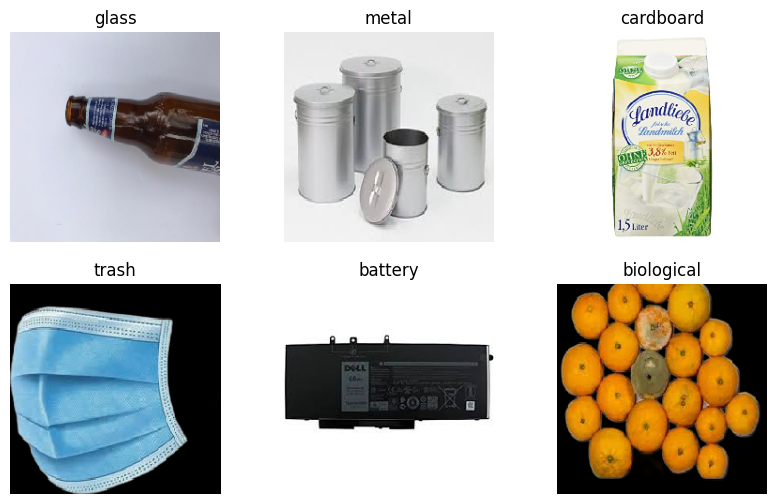

In [7]:
print("Random Training Images (Before Augmentation)")
show_random_images(TRAIN_PATH)

Random Testing Images (Before Augmentation)


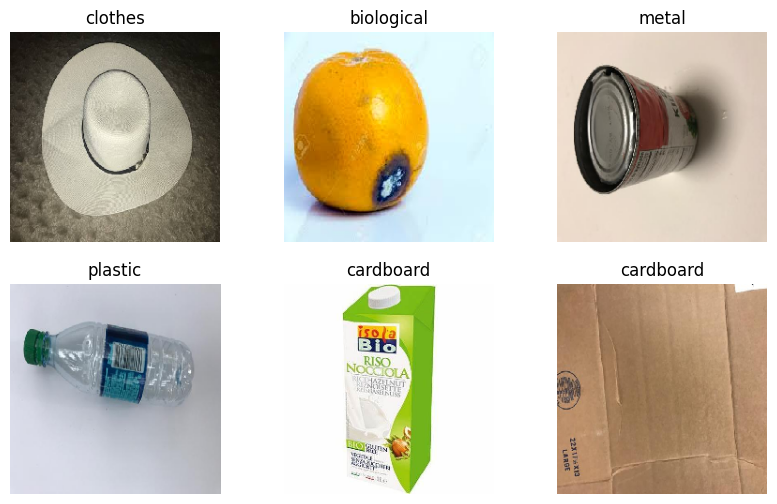

In [7]:
print("Random Testing Images (Before Augmentation)")
show_random_images(TEST_PATH)

In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=False,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "/Train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    DATASET_PATH + "/Test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Number of training samples (per epoch):", train_generator.samples)
print("Number of test samples:", test_generator.samples)

Found 19009 images belonging to 10 classes.
Found 1579 images belonging to 10 classes.
Number of training samples (per epoch): 19009
Number of test samples: 1579


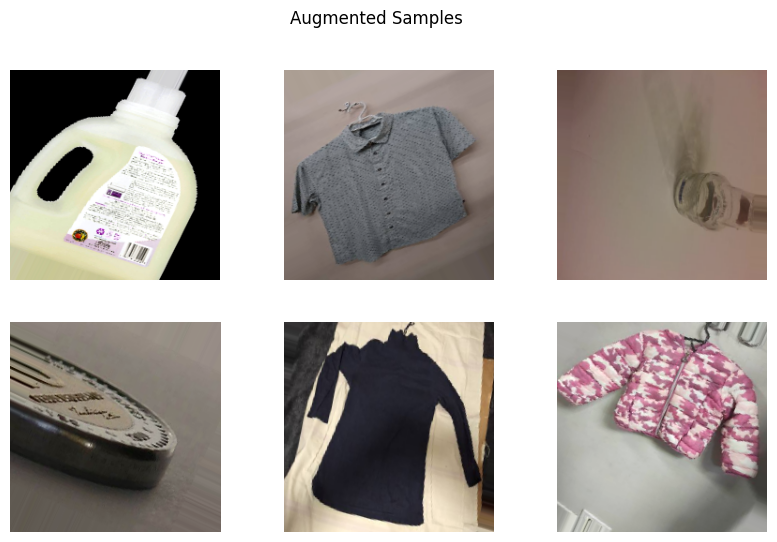

In [9]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Augmented Samples")
plt.show()

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [11]:
num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

base_model = MobileNetV2(
    weights="/kaggle/input/models/atulsonii/mobile-net-weights/keras/default/1/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

2026-02-16 02:50:50.207023: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.5577 - loss: 1.3895 - val_accuracy: 0.8581 - val_loss: 0.4389 - learning_rate: 1.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 758s 1s/step - accuracy: 0.8142 - loss: 0.5755 - val_accuracy: 0.8961 - val_loss: 0.3315 - learning_rate: 1.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 753s 1s/step - accuracy: 0.8500 - loss: 0.4689 - val_accuracy: 0.9088 - val_loss: 0.2824 - learning_rate: 1.0000e-04
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 758s 1s/step - accuracy: 0.8617 - loss: 0.4291 - val_accuracy: 0.9145 - val_loss: 0.2650 - learning_rate: 1.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 743s 1s/step - accuracy: 0.8746 - loss: 0.3862 - val_accuracy: 0.9278 - val_loss: 0.2396 - learning_rate: 1.0000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 742s 1s/step - accuracy: 0.8825 - loss: 0.3629 - val_accuracy: 0.9234 - val_loss: 0.2352 - learning_rate: 1.0000e-04
Epoch 7/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - acc

In [17]:
# Predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 809ms/step
Accuracy: 0.9512349588347055


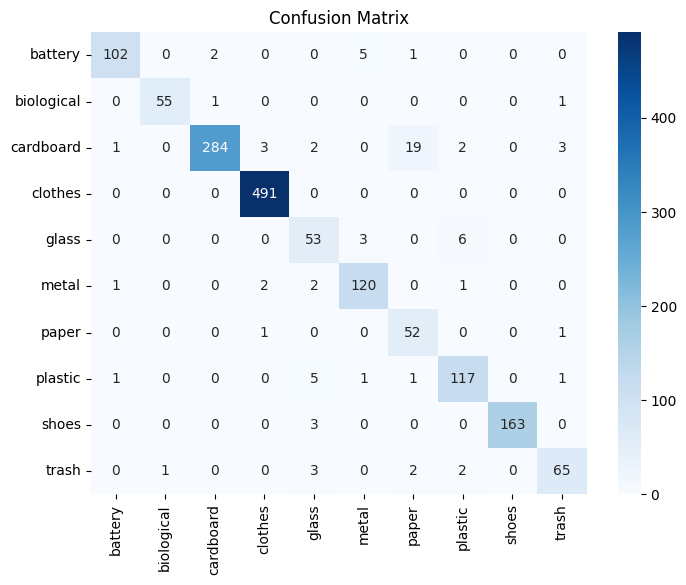

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

     battery       0.97      0.93      0.95       110
  biological       0.98      0.96      0.97        57
   cardboard       0.99      0.90      0.95       314
     clothes       0.99      1.00      0.99       491
       glass       0.78      0.85      0.82        62
       metal       0.93      0.95      0.94       126
       paper       0.69      0.96      0.81        54
     plastic       0.91      0.93      0.92       126
       shoes       1.00      0.98      0.99       166
       trash       0.92      0.89      0.90        73

    accuracy                           0.95      1579
   macro avg       0.92      0.94      0.92      1579
weighted avg       0.96      0.95      0.95      1579



In [20]:
# ROC AUC
y_true_bin = label_binarize(y_true, classes=range(num_classes))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class="ovr")
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9978708794673302


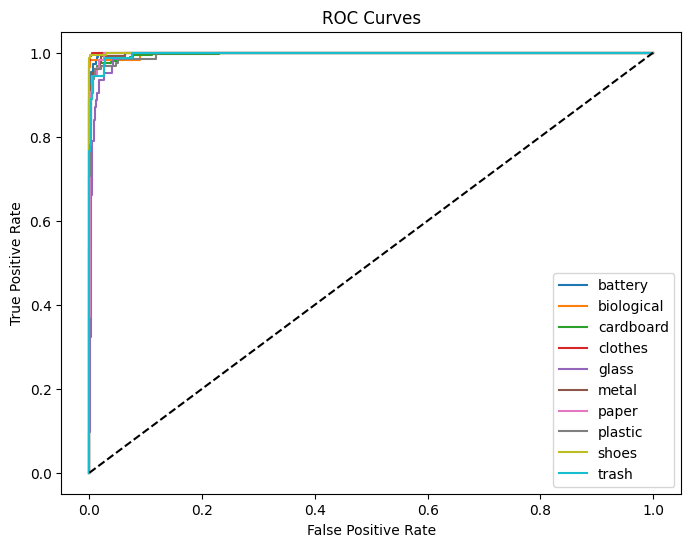

In [21]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


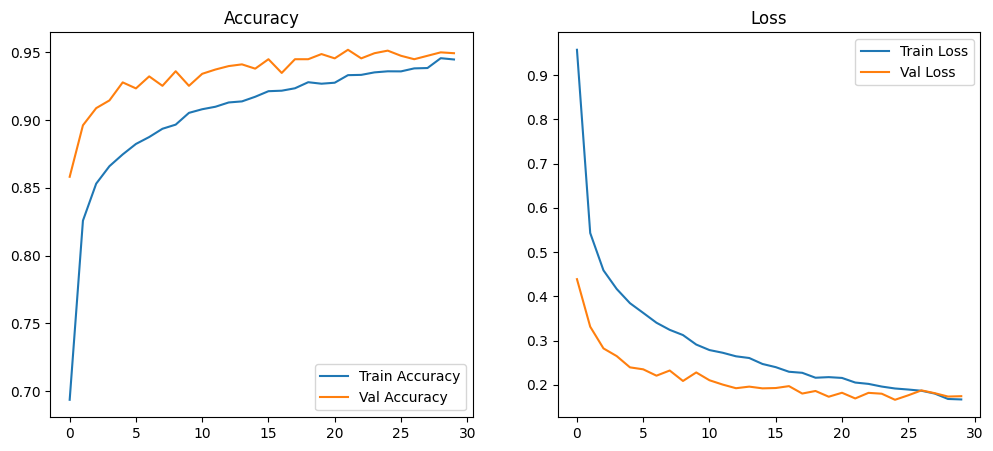

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [23]:
model.save("waste_classification_mobilenet.h5")
print("Model saved successfully")

Model saved successfully


In [24]:
import tensorflow as tf

# Load saved model
model = tf.keras.models.load_model("waste_classification_mobilenet.h5")

# Create converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# IMPORTANT: Keep default settings for maximum compatibility
converter.optimizations = []   # No aggressive optimization
converter.target_spec.supported_types = [tf.float32]

tflite_model = converter.convert()

# Save TFLite model
with open("waste_classification_mobilenet.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")


INFO:tensorflow:Assets written to: /tmp/tmpt7flgdte/assets


INFO:tensorflow:Assets written to: /tmp/tmpt7flgdte/assets


Saved artifact at '/tmp/tmpt7flgdte'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137357543549328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543544144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543545104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543545296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543544528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543546832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543543952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543544336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543549712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543544912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137357543543

W0000 00:00:1771234784.810879      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771234784.811003      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1771234785.007095      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model saved successfully!
